In [1]:
##defino variables

import sympy as sp

#definimos variables
sigmax=sp.symbols("sigma_x")
sigmay=sp.symbols("sigma_y")
sigmaz=sp.symbols("sigma_z")
tauxy=sp.symbols("tau_xy")
tauxz=sp.symbols("tau_xz")
tauyz=sp.symbols("tau_yz")

ModuloElasticidad=sp.symbols("E")
V=sp.symbols("nu")

#defino sigma medio
sigma_M=(sigmax+sigmay+sigmaz)/3


para la matriz de esfuerzos hidroestaticos

In [2]:
##invariantes Itilde  hidroestaticos desde 0

#defino el tensor de esfuerzos hidroestaticos
matrixSigmaM=sp.Matrix([
    [sigma_M,0,0],
    [0,sigma_M,0],
    [0,0,sigma_M]
])
##definimos los esfuerzos principales del tensor hidroestaticos
sigman1=sp.symbols("sigma_nh")
##lo uso para hallar el polinomio usando la ecuacion 1
I=sp.Matrix([
    [1,0,0],
    [0,1,0],
    [0,0,1]
])

operacion1=matrixSigmaM-(sigman1*I)
polinomio1=operacion1.det()
polinomio1_simpificado=sp.collect(polinomio1,sigman1)


invariante1tilde=polinomio1_simpificado.coeff(sigman1, 2)  #va de derecha a izquierda empezando desde el cero

invariante2tilde=-(polinomio1_simpificado.coeff(sigman1,1))

invariante3tilde=polinomio1_simpificado.coeff(sigman1,0)


display(matrixSigmaM)
display(polinomio1_simpificado)
print("invariante Í1")
display(invariante1tilde)
print("invariante Í2")
display(invariante2tilde)
print("invariante Í3")
display(invariante3tilde)
print("-----------------------------------------------------------------------------------------------------------------------------------------------")

Matrix([
[sigma_x/3 + sigma_y/3 + sigma_z/3,                                 0,                                 0],
[                                0, sigma_x/3 + sigma_y/3 + sigma_z/3,                                 0],
[                                0,                                 0, sigma_x/3 + sigma_y/3 + sigma_z/3]])

-sigma_nh**3 + sigma_nh**2*(sigma_x + sigma_y + sigma_z) + sigma_nh*(-sigma_x**2/3 - 2*sigma_x*sigma_y/3 - 2*sigma_x*sigma_z/3 - sigma_y**2/3 - 2*sigma_y*sigma_z/3 - sigma_z**2/3) + sigma_x**3/27 + sigma_x**2*sigma_y/9 + sigma_x**2*sigma_z/9 + sigma_x*sigma_y**2/9 + 2*sigma_x*sigma_y*sigma_z/9 + sigma_x*sigma_z**2/9 + sigma_y**3/27 + sigma_y**2*sigma_z/9 + sigma_y*sigma_z**2/9 + sigma_z**3/27

invariante Í1


sigma_x + sigma_y + sigma_z

invariante Í2


sigma_x**2/3 + 2*sigma_x*sigma_y/3 + 2*sigma_x*sigma_z/3 + sigma_y**2/3 + 2*sigma_y*sigma_z/3 + sigma_z**2/3

invariante Í3


sigma_x**3/27 + sigma_x**2*sigma_y/9 + sigma_x**2*sigma_z/9 + sigma_x*sigma_y**2/9 + 2*sigma_x*sigma_y*sigma_z/9 + sigma_x*sigma_z**2/9 + sigma_y**3/27 + sigma_y**2*sigma_z/9 + sigma_y*sigma_z**2/9 + sigma_z**3/27

-----------------------------------------------------------------------------------------------------------------------------------------------


para ahorrar tiempo el proceso siguiente se ara con una funcion que calcula:
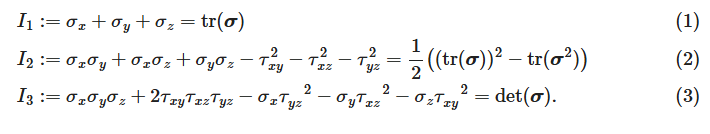

In [31]:
def invariantes(matrix_de_esfuerzos):
    I1=matrix_de_esfuerzos.trace()
    I2=(1/2)*(((matrix_de_esfuerzos.trace())**2)-(((matrix_de_esfuerzos)**2).trace()))
    I3=matrix_de_esfuerzos.det()
    return I1,I2,I3


In [32]:
##comprbamos LOS INVARIANTES HIDRO ESTATICOS
I1,I2,I3=sp.nsimplify(invariantes(matrixSigmaM)) #el sp.nsimplify es para que salga fraccion
display(I1,I2,I3)

sigma_x + sigma_y + sigma_z

-3*(sigma_x/3 + sigma_y/3 + sigma_z/3)**2/2 + (sigma_x + sigma_y + sigma_z)**2/2

sigma_x**3/27 + sigma_x**2*sigma_y/9 + sigma_x**2*sigma_z/9 + sigma_x*sigma_y**2/9 + 2*sigma_x*sigma_y*sigma_z/9 + sigma_x*sigma_z**2/9 + sigma_y**3/27 + sigma_y**2*sigma_z/9 + sigma_y*sigma_z**2/9 + sigma_z**3/27

In [19]:
#comprobamos los invariantes desviadores
#defino los esfuerzo deviadores
#por definicion
desviadoresx=(sigmax-sigma_M)
desviadoresy=(sigmay-sigma_M)
desviadoresz=(sigmaz-sigma_M)
##creo la matriz de los desviadores
s=sp.Matrix([
    [desviadoresx,tauxy,tauxz],
    [tauxy,desviadoresy,tauyz],
    [tauxz,tauyz,desviadoresz]
])
display(s)
print("J1,J2,J3")
J1,J2,J3=sp.nsimplify(invariantes(s)) #el sp.nsimplify es para que salga fraccion
display(I1,I2,I3)
print("------------------------------------------------------------------------------------------------------------------------------------------------")

Matrix([
[2*sigma_x/3 - sigma_y/3 - sigma_z/3,                               tau_xy,                               tau_xz],
[                             tau_xy, -sigma_x/3 + 2*sigma_y/3 - sigma_z/3,                               tau_yz],
[                             tau_xz,                               tau_yz, -sigma_x/3 - sigma_y/3 + 2*sigma_z/3]])

J1,J2,J3


0

-sigma_x**2/3 + sigma_x*sigma_y/3 + sigma_x*sigma_z/3 - sigma_y**2/3 + sigma_y*sigma_z/3 - sigma_z**2/3 - tau_xy**2 - tau_xz**2 - tau_yz**2

2*sigma_x**3/27 - sigma_x**2*sigma_y/9 - sigma_x**2*sigma_z/9 - sigma_x*sigma_y**2/9 + 4*sigma_x*sigma_y*sigma_z/9 - sigma_x*sigma_z**2/9 + sigma_x*tau_xy**2/3 + sigma_x*tau_xz**2/3 - 2*sigma_x*tau_yz**2/3 + 2*sigma_y**3/27 - sigma_y**2*sigma_z/9 - sigma_y*sigma_z**2/9 + sigma_y*tau_xy**2/3 - 2*sigma_y*tau_xz**2/3 + sigma_y*tau_yz**2/3 + 2*sigma_z**3/27 - 2*sigma_z*tau_xy**2/3 + sigma_z*tau_xz**2/3 + sigma_z*tau_yz**2/3 + 2*tau_xy*tau_xz*tau_yz

------------------------------------------------------------------------------------------------------------------------------------------------


ahora hallaremos los invariantes hidroestaticos en funcion de sigma

In [16]:
sigmam=sp.symbols("sigma_m")
matrixm=sp.Matrix([
    [sigmam,0,0],
    [0,sigmam,0],
    [0,0,sigmam]
])
print("invariantes Í1,Í2,Í3 hidroestaticos usando el esfuerzo medio")
I1,I2,I3=sp.nsimplify(invariantes(matrixm))
display(I1,I2,I3)


invariantes Í1,Í2,Í3 hidroestaticos usando el esfuerzo medio


3*sigma_m

3*sigma_m**2

sigma_m**3

ahora veremos si la expresion j2 es igual a alguna de estas
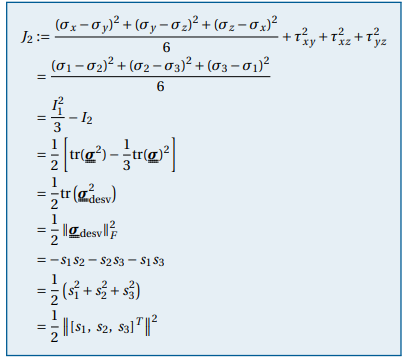

In [22]:
matrizEsfuerzos=sp.Matrix([
    [sigmax,tauxy,tauxz],
    [tauxy,sigmay,tauyz],
    [tauxz,tauyz,sigmaz]])
I1,I2,I3=sp.nsimplify(invariantes(matrizEsfuerzos))
display(I1,I2,I3)
print("------------------------------------------------")
display(J2)


sigma_x + sigma_y + sigma_z

-sigma_x**2/2 - sigma_y**2/2 - sigma_z**2/2 - tau_xy**2 - tau_xz**2 - tau_yz**2 + (sigma_x + sigma_y + sigma_z)**2/2

sigma_x*sigma_y*sigma_z - sigma_x*tau_yz**2 - sigma_y*tau_xz**2 - sigma_z*tau_xy**2 + 2*tau_xy*tau_xz*tau_yz

------------------------------------------------


-sigma_x**2/3 + sigma_x*sigma_y/3 + sigma_x*sigma_z/3 - sigma_y**2/3 + sigma_y*sigma_z/3 - sigma_z**2/3 - tau_xy**2 - tau_xz**2 - tau_yz**2

In [34]:
-J2.equals(((I1**2)/3) - I2) #se pone el negativo por la convencion de signos dle libro debido a que en un futuro se usara

0

NOTA: LA FUNCION YA TIENE LA CONVENCION DE SIGNOS DE I2, POR ESO I2 TILDE DA DIRECTO, EN J2 ESTA CONVENCION SE DEBE REMOVER